# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
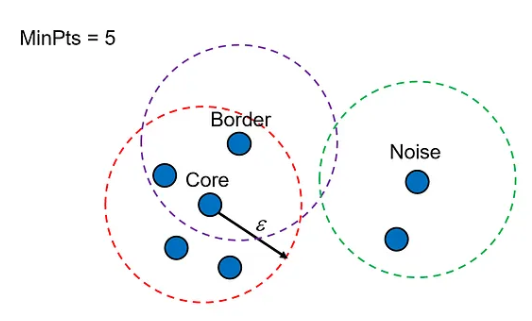

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

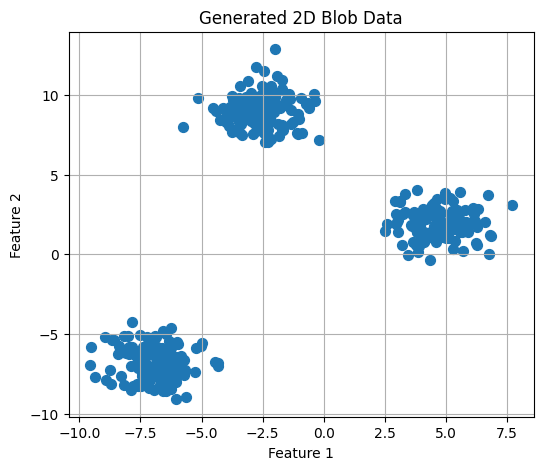

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

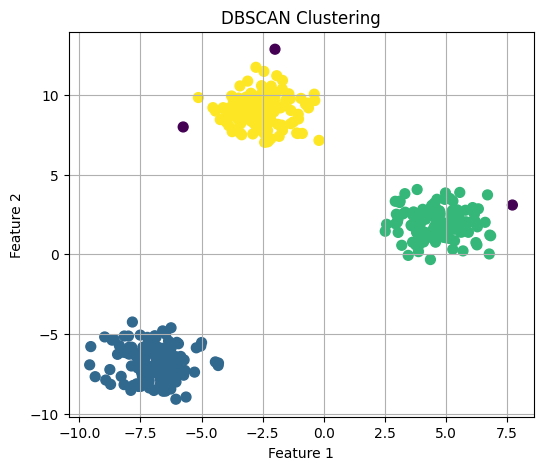

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

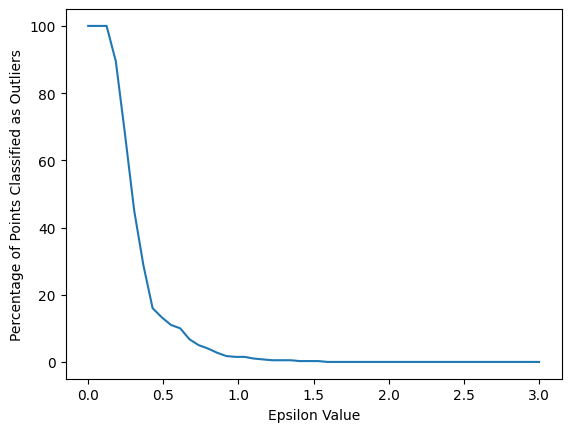

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

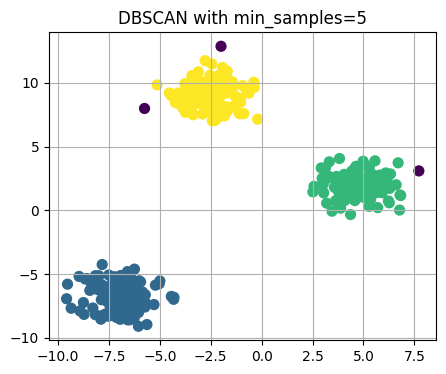

min_samples=5 → Silhouette Score: 0.848


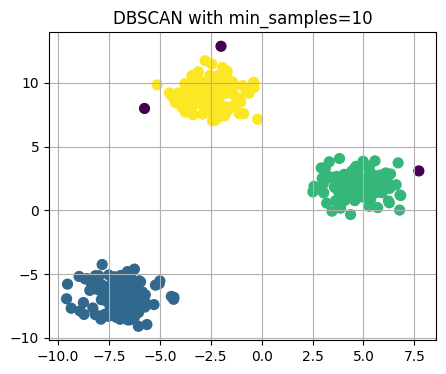

min_samples=10 → Silhouette Score: 0.848


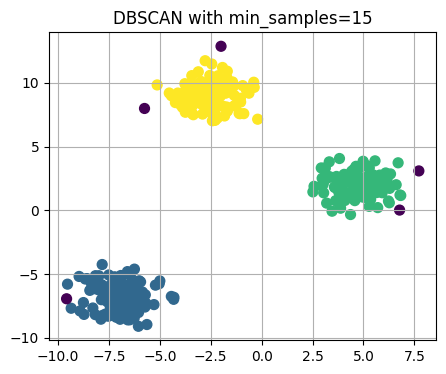

min_samples=15 → Silhouette Score: 0.849


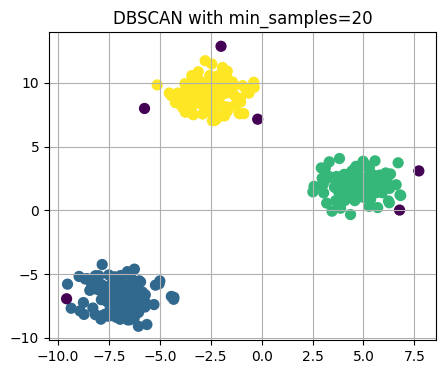

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. Load the dataset
# =====================================================================
# Read the CSV file into a Pandas DataFrame
df = pd.read_csv('CC GENERAL.csv')

# =====================================================================
# 2. Identify numeric vs categorical features
# =====================================================================
# df.info() provides a concise summary of the dataframe including column data types and non-null counts
print("--- Data Info (Numeric vs Categorical) ---")
df.info()

# We can also dynamically extract categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n--- Categorical Features ---")
print(categorical_cols.tolist())









--- Data Info (Numeric vs Categorical) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX          

In [6]:
# =====================================================================
# 3. Check counts of categories for categorical features
# =====================================================================
# In this dataset, 'CUST_ID' is the only categorical feature.
# We check how many unique values it has to understand its cardinality.
for col in categorical_cols:
    print(f"\nFeature: {col}, Unique Values: {df[col].nunique()}")

# =====================================================================
# 4. Identify missing or unknown values
# =====================================================================
# df.isnull().sum() counts the number of missing (NaN) values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())
# =====================================================================
# 5. Check distributions of numeric features (min, max, mean, std, skewness)
# =====================================================================
print("\n--- Numeric Distributions ---")
# df.describe() computes standard summary statistics for numeric columns
desc = df.describe().T

# We calculate skewness separately because it is highly relevant for clustering algorithms
# Skewness tells us if the data is symmetrical or skewed to one side (high outliers)
desc['skewness'] = df.select_dtypes(include=[np.number]).skew()

# Displaying only the requested statistics for clarity
print(desc[['mean', 'std', 'min', 'max', 'skewness']])


Feature: CUST_ID, Unique Values: 8950

--- Missing Values ---
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

--- Numeric Distributions ---
                                         mean          std        min  \
BALANCE                           1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY          

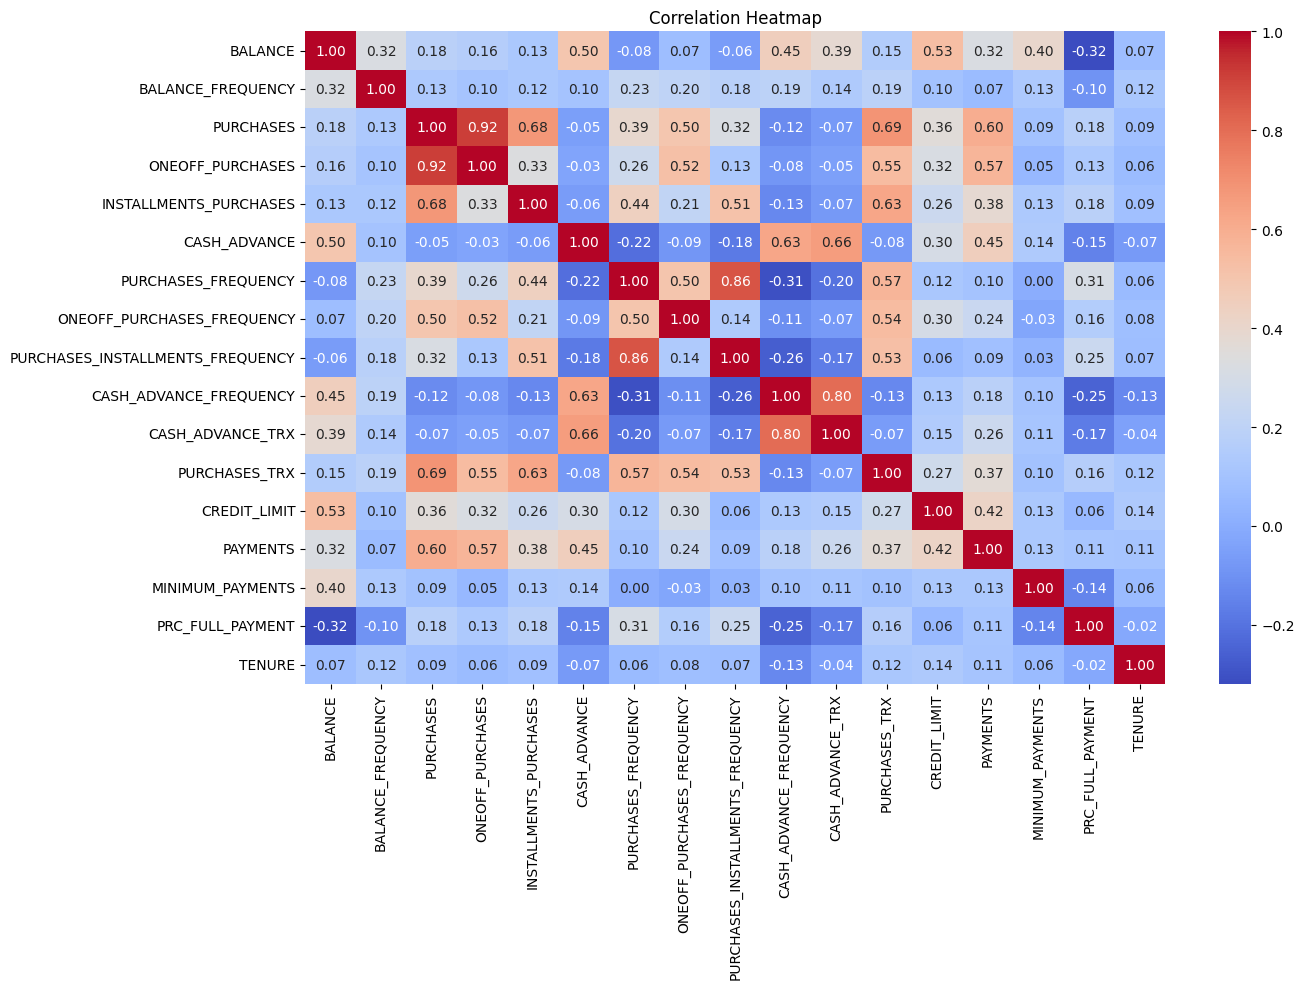

In [4]:
# =====================================================================
# 6. Look for correlations between numeric features
# =====================================================================
# Calculate the Pearson correlation matrix (dropping CUST_ID as it is non-numeric)
corr_matrix = df.drop(columns=['CUST_ID']).corr()

# Plotting the correlation heatmap
plt.figure(figsize=(14, 10))
# annot=True displays the actual correlation values inside the squares
# cmap='coolwarm' uses blue for negative correlation and red for positive correlation
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show() # Use plt.savefig('heatmap.png') if you want to save it to a file instead

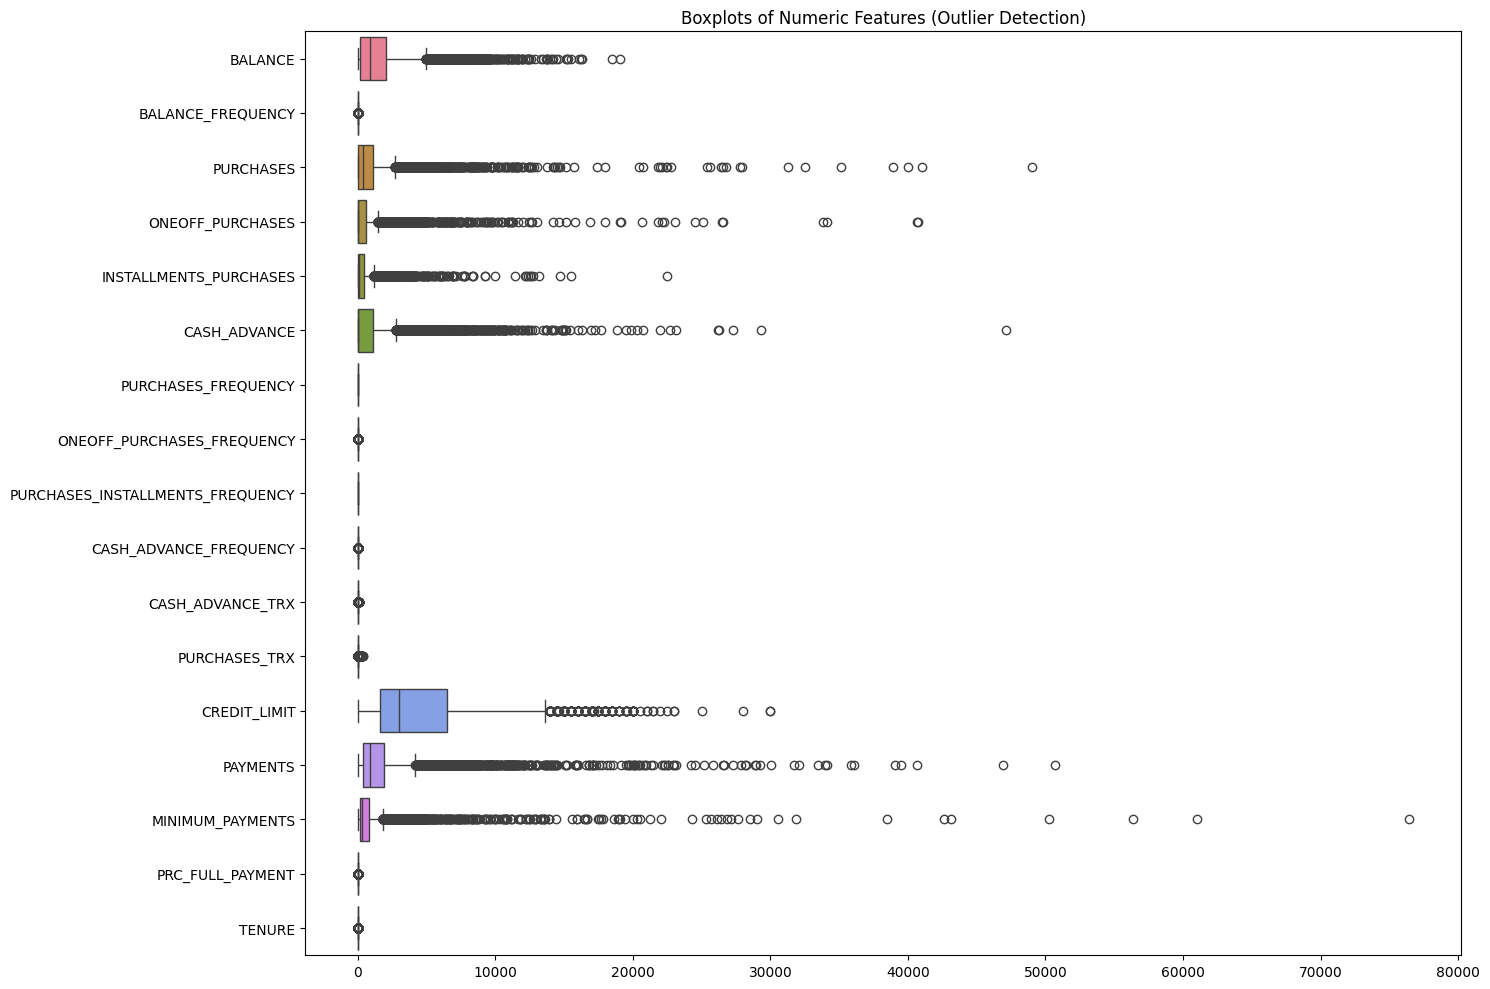

In [5]:
# =====================================================================
# 7. Identify outliers that may affect clustering
# =====================================================================
# We use boxplots to visualize the distribution and outliers of each numeric feature
plt.figure(figsize=(15, 10))

# orient='h' plots the boxes horizontally to make the long feature names readable
# We drop CUST_ID again to only plot numeric values
sns.boxplot(data=df.drop(columns=['CUST_ID']), orient='h')
plt.title('Boxplots of Numeric Features (Outlier Detection)')
plt.tight_layout()
plt.show() # Use plt.savefig('boxplots.png') if you want to save it to a file instead

## 2. Data Preparation

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. Load the dataset
# =====================================================================
df = pd.read_csv('CC GENERAL.csv')

# =====================================================================
# 2. Drop irrelevant columns
# =====================================================================
# We drop CUST_ID because it's an arbitrary string identifier. 
# It provides no behavioral pattern and will ruin distance calculations.
df_prep = df.drop(columns=['CUST_ID'])





In [ ]:
# =====================================================================
# 3. Handle missing values
# =====================================================================
# We use the median to fill missing values instead of the mean because 
# EDA showed extreme right-skewness (huge outliers). 
# The median is robust against extreme outliers.
median_min_payments = df_prep['MINIMUM_PAYMENTS'].median()
df_prep['MINIMUM_PAYMENTS'] = df_prep['MINIMUM_PAYMENTS'].fillna(median_min_payments)

median_credit_limit = df_prep['CREDIT_LIMIT'].median()
df_prep['CREDIT_LIMIT'] = df_prep['CREDIT_LIMIT'].fillna(median_credit_limit)

# =====================================================================
# 4. Handle Skewness (Log Transformation)
# =====================================================================
# Because the financial data is extremely skewed, algorithms like 
# DBSCAN will struggle. A Log Transformation heavily reduces the impact of 
# extreme outliers. We use np.log(1 + x) instead of np.log(x) because our data 
# contains zeros, and log(0) is undefined (infinity).
df_log = np.log(1 + df_prep)

# =====================================================================
# 5. Scale numeric features
# =====================================================================
# StandardScaler ensures that all features have a mean of 0 and standard deviation of 1.
# This makes features with small decimal ranges (like frequency) exactly as 
# important as features with large monetary ranges (like Balance).
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_log)

# Convert the scaled array back into a pandas DataFrame for easier viewing/handling
df_scaled = pd.DataFrame(df_scaled_array, columns=df_log.columns)

In [9]:
# =====================================================================
# 6. Verification
# =====================================================================
print("--- Final Dataset Verification ---")
# Check that there are absolutely no missing values left
print(f"Total Missing Values: {df_scaled.isnull().sum().sum()}") 

# Check that every single column is numeric (float64)
print(f"\nData Types:\n{df_scaled.dtypes.unique()}") 

# Check the final shape to ensure we still have all 8950 rows and our 17 features
print(f"\nShape of prepared data: {df_scaled.shape}")

--- Final Dataset Verification ---
Total Missing Values: 0

Data Types:
[dtype('float64')]

Shape of prepared data: (8950, 17)


## 3. Apply DBSCAN




In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# =====================================================================
# STEP 3: Initial "Random" DBSCAN & Visualization
# =====================================================================
print("--- Running Initial Random DBSCAN ---")

# 1. Apply DBSCAN with arbitrary/random parameters to establish a baseline
initial_eps = 1.0
initial_min_samples = 10

dbscan_init = DBSCAN(eps=initial_eps, min_samples=initial_min_samples)
labels_init = dbscan_init.fit_predict(df_scaled)








--- Running Initial Random DBSCAN ---


In [25]:
# 2. PCA Dimensionality Reduction
# We reduce the 17 features to 2 Principal Components (2D). 
# 2D is the most suitable because it captures the majority of the variance (~56%)
# while being significantly easier to visualize and interpret than a 3D scatter plot.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

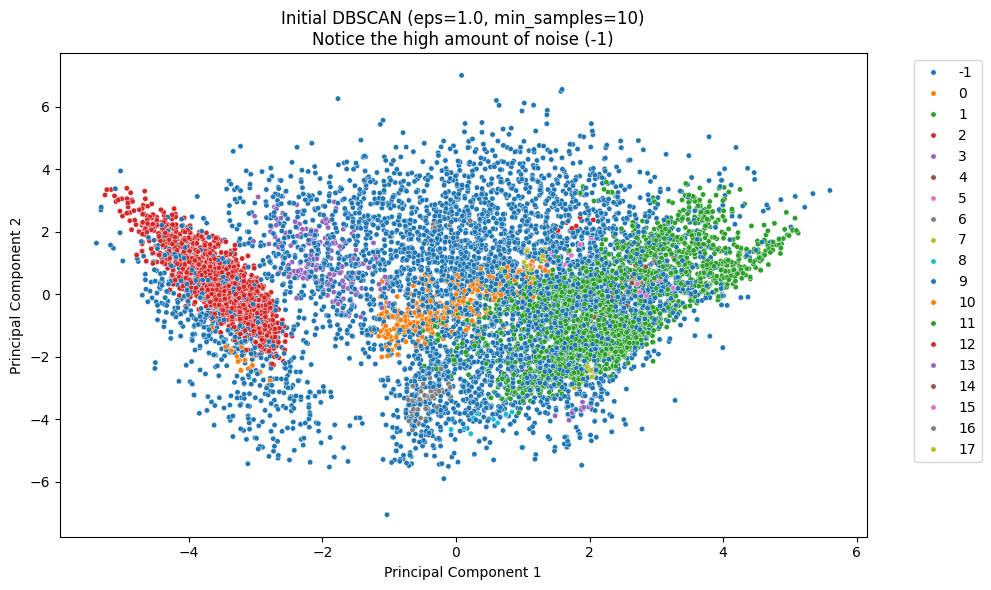

In [26]:
# 3. Visualize Initial DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_result[:, 0], 
    y=pca_result[:, 1], 
    hue=labels_init, 
    palette='tab10', 
    legend='full', 
    s=15
)
plt.title(f'Initial DBSCAN (eps={initial_eps}, min_samples={initial_min_samples})\nNotice the high amount of noise (-1)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## 4. Evaluate the Clustering


--- Plotting K-Distance Graph ---


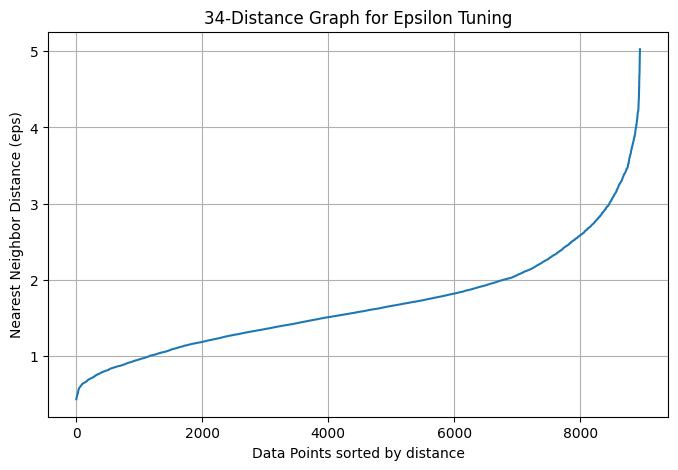

In [27]:
# =====================================================================
# STEP 4: Evaluation, Tuning, and Final Application
# =====================================================================

# --- 4.1 K-Distance Graph (Finding the starting eps) ---
print("\n--- Plotting K-Distance Graph ---")
# We use k = 34 (which is 2 * 17 features)
k = 34 
nn = NearestNeighbors(n_neighbors=k)
nn.fit(df_scaled)
distances, indices = nn.kneighbors(df_scaled)

# Sort the distances to the 34th nearest neighbor to find the elbow
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f'{k}-Distance Graph for Epsilon Tuning')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Nearest Neighbor Distance (eps)')
plt.grid(True)
plt.show() 


In [28]:
# --- 4.2 The Tuning Loop ---
print("\n--- Running Tuning Loop ---")
# Find the approximate elbow point mathematically (around the 95th percentile)
elbow_approx = np.percentile(k_distances, 95) 

# Test different eps values around the elbow
eps_values = np.linspace(elbow_approx * 0.5, elbow_approx * 1.5, 6) 
# Test min_samples: 1x features (17), 2x features (34), and a stricter value (50)
min_samples_values = [17, 34, 50] 

results = []

for e in eps_values:
    for ms in min_samples_values:
        # Apply DBSCAN
        db = DBSCAN(eps=e, min_samples=ms)
        labels = db.fit_predict(df_scaled)
        
        # Track Outliers (-1 label)
        n_outliers = np.sum(labels == -1)
        outlier_pct = (n_outliers / len(labels)) * 100
        
        # Calculate Silhouette Score (Ignoring Noise points)
        # We ignore noise because DBSCAN's purpose is to filter it out. 
        # Including noise artificially lowers the score of the actual dense clusters.
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        
        if n_clusters > 1:
            sil_score = silhouette_score(df_scaled[mask], labels[mask])
        else:
            sil_score = -1 # Invalid score for 1 or 0 valid clusters
            
        results.append({
            'eps': round(e, 2),
            'min_samples': ms,
            'n_clusters': n_clusters,
            'outlier_pct': round(outlier_pct, 2),
            'silhouette': round(sil_score, 4)
        })

results_df = pd.DataFrame(results)

# Filter for the best models: High silhouette score, but keeping outliers under a reasonable 40%
valid_models = results_df[(results_df['outlier_pct'] < 40) & (results_df['n_clusters'] > 1)]

# Select the absolute best model based on the highest Silhouette score
best_model = valid_models.loc[valid_models['silhouette'].idxmax()]
print("\nBest Model Selected by Loop:")
print(best_model)



--- Running Tuning Loop ---

Best Model Selected by Loop:
eps             2.1400
min_samples    17.0000
n_clusters      2.0000
outlier_pct     5.2300
silhouette      0.2965
Name: 3, dtype: float64



--- Applying Final Tuned DBSCAN ---


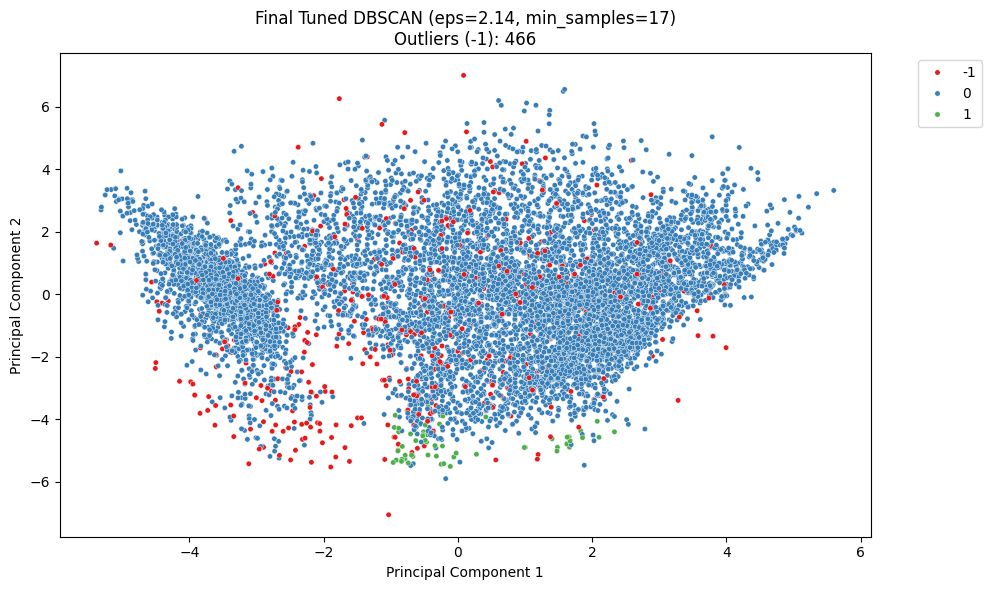

In [30]:


# --- 4.3 Apply Final Tuned DBSCAN ---
print("\n--- Applying Final Tuned DBSCAN ---")
final_eps = best_model['eps']
final_ms = int(best_model['min_samples'])

dbscan_final = DBSCAN(eps=final_eps, min_samples=final_ms)
labels_final = dbscan_final.fit_predict(df_scaled)


# --- 4.4 Final Tuned Visualization ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_result[:, 0], 
    y=pca_result[:, 1], 
    hue=labels_final, 
    palette='Set1', 
    legend='full', 
    s=15
)
plt.title(f'Final Tuned DBSCAN (eps={final_eps}, min_samples={final_ms})\nOutliers (-1): {np.sum(labels_final==-1)}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()